
# BANK MARKETING PREDICTION USING DECISION TREE CLASSIFIER


# Domain : Machine Learning
# Algorithm : Decision Tree Classifier
# Dataset : Bank Marketing Dataset (UCI Repository)

# Project Objective:
# Predict whether a customer will subscribe to a term deposit
# based on demographic and behavioral information.

In [35]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import (DecisionTreeClassifier,plot_tree)

from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

import joblib

plt.style.use("ggplot")

In [36]:
# Load Dataset


df = pd.read_csv('/content/bank-full.csv',sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [37]:
# ==========================================
# Display First 10 Records
# ==========================================

df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [38]:
# Dataset Shape

print("Dataset Shape :",df.shape)

Dataset Shape : (45211, 17)


In [39]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [40]:
# Statistical Summary
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [41]:
# Check Missing Values

df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [42]:
# Check Duplicate Records
print(
    "Duplicate Records :",
    df.duplicated().sum()
)

Duplicate Records : 0


/tmp/ipykernel_1338/1708529616.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="y",data=df,palette="viridis")


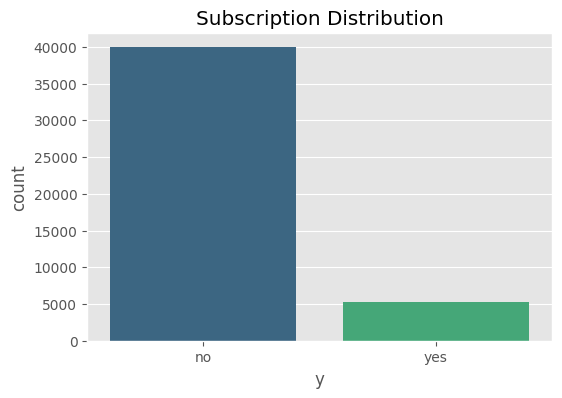

In [43]:
# Target Variable Distribution

plt.figure(figsize=(6,4))

sns.countplot(x="y",data=df,palette="viridis")

plt.title("Subscription Distribution")

plt.show()

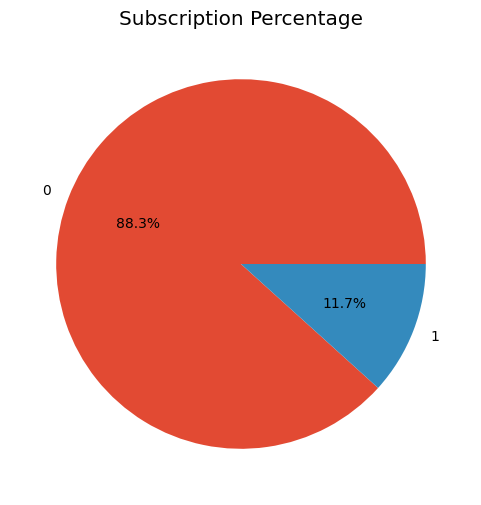

In [69]:
# Subscription Percentage Pie Chart

plt.figure(figsize=(6,6))

df["y"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.title("Subscription Percentage")

plt.show()

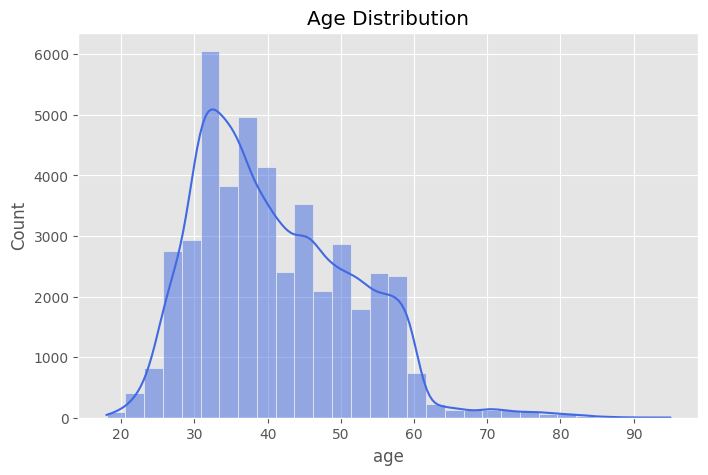

In [70]:
# Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["age"],bins=30,kde=True,color="royalblue")

plt.title("Age Distribution")

plt.show()

/tmp/ipykernel_1338/444711648.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="job",data=df,order=df["job"].value_counts().index,palette="magma")


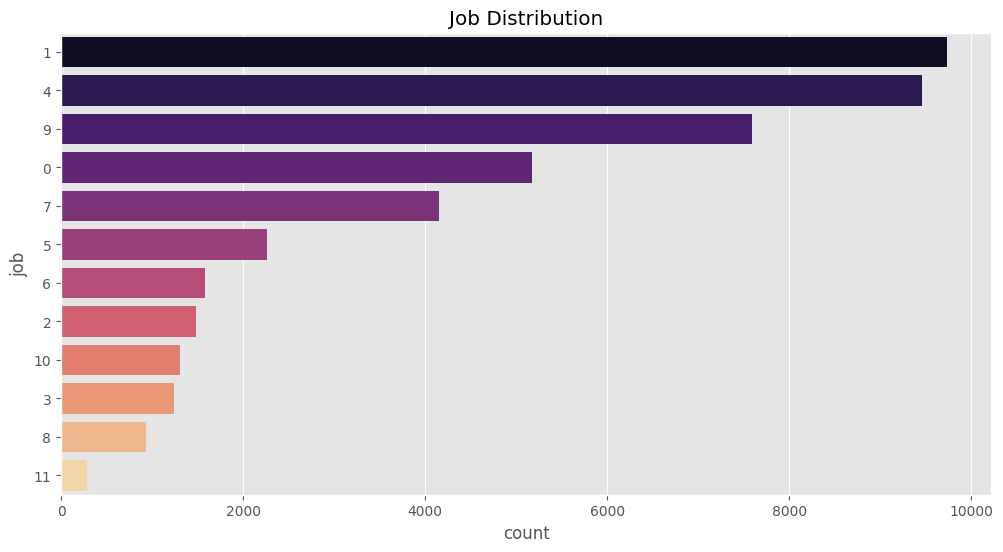

In [71]:
# Job Distribution

plt.figure(figsize=(12,6))

sns.countplot(y="job",data=df,order=df["job"].value_counts().index,palette="magma")

plt.title("Job Distribution")

plt.show()

/tmp/ipykernel_1338/2531561039.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="marital", data=df,palette="Set2")


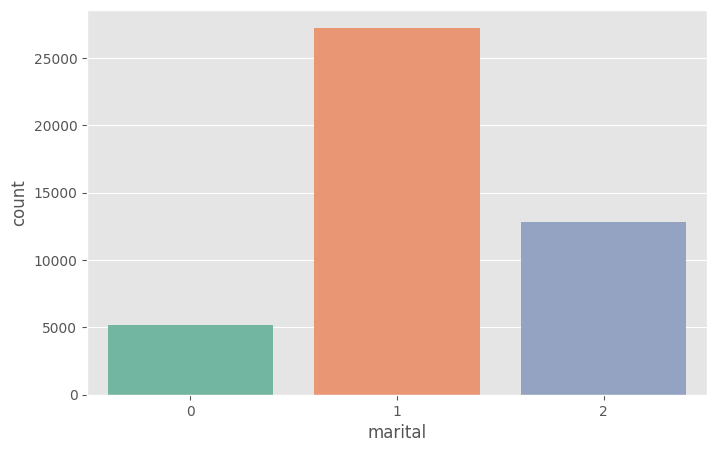

In [79]:
# Marital Status Distribution

plt.figure(figsize=(8,5))

sns.countplot(x="marital", data=df,palette="Set2")

plt.show()

# 0 = divorced, 1 = married ,2 = single

/tmp/ipykernel_1338/4180139465.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="education",data=df,palette="coolwarm")


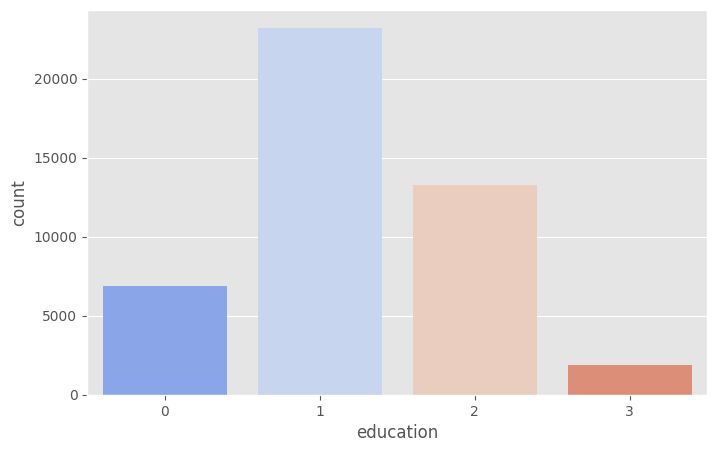

In [75]:
# Education Distribution

plt.figure(figsize=(8,5))

sns.countplot(x="education",data=df,palette="coolwarm")

plt.show()

/tmp/ipykernel_1338/2221948231.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="y",y="age",data=df,palette="Set3")


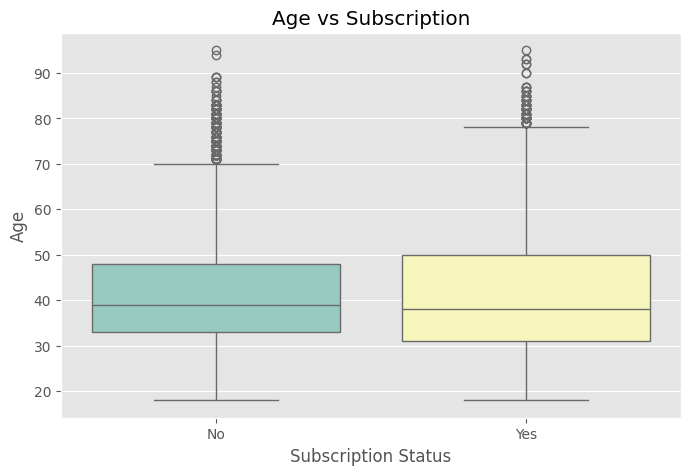

In [78]:
# Age vs Subscription


plt.figure(figsize=(8,5))

sns.boxplot(x="y",y="age",data=df,palette="Set3")

plt.title("Age vs Subscription")

plt.xlabel("Subscription Status")

plt.xticks([0,1],["No","Yes"])

plt.ylabel( "Age")

plt.show()

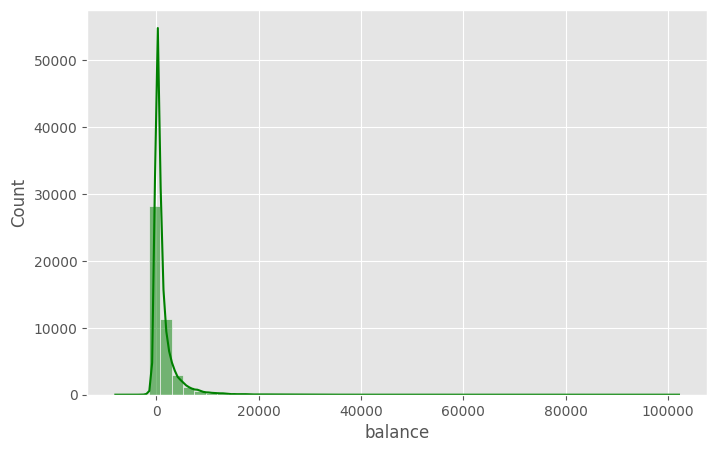

In [80]:
# Balance Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["balance"],bins=50,kde=True,color="green")

plt.show()

In [83]:

# Encode Categorical Variables

encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype == "object":

        df[col] = encoder.fit_transform(df[col])

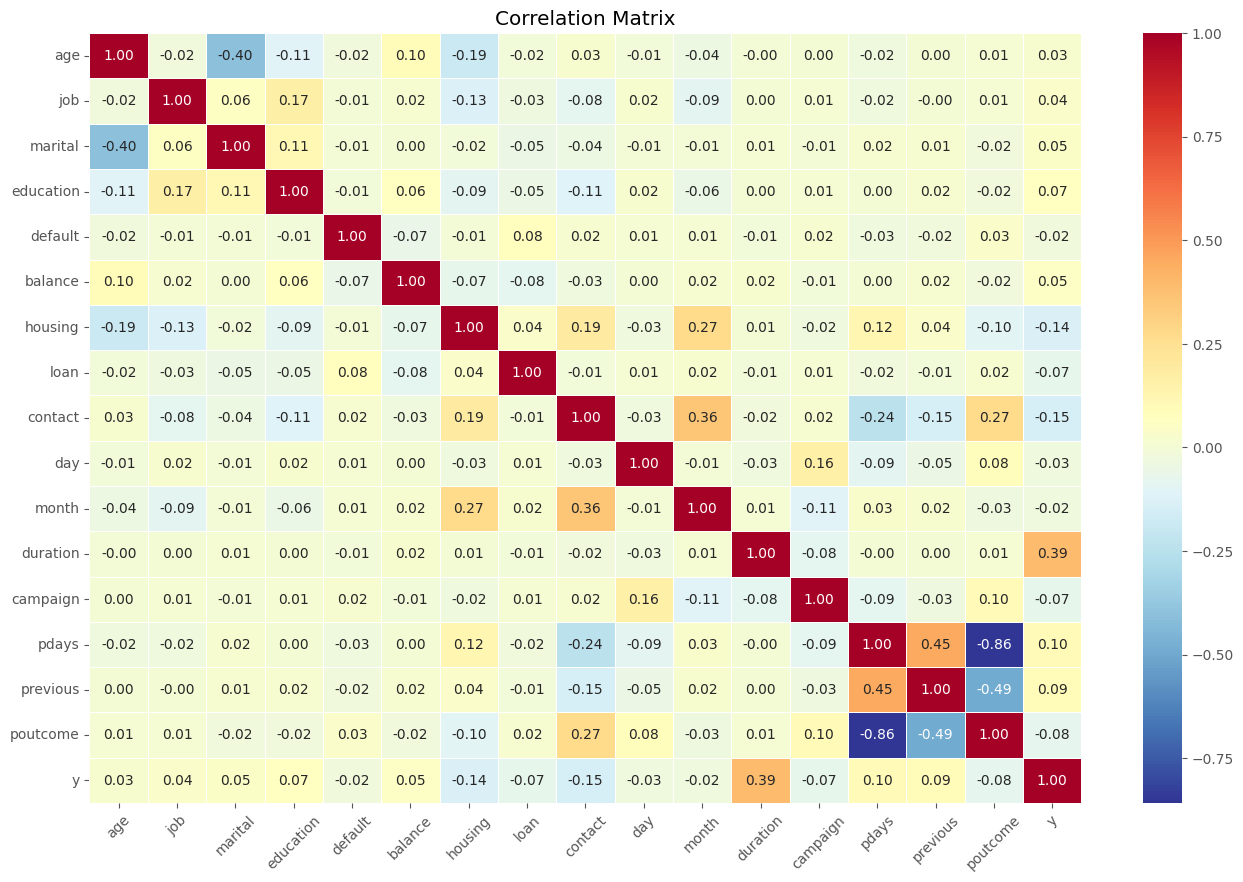

In [85]:
# Correlation Matrix

plt.figure(figsize=(16,10))

sns.heatmap(df.corr(),annot=True,fmt=".2f",cmap="RdYlBu_r",linewidths=0.5)

plt.title("Correlation Matrix")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.show()

In [86]:
# Define Features and Target

X = df.drop("y",axis=1)
y = df["y"]

In [87]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [88]:
# Create Decision Tree Model

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

In [89]:
# Train Decision Tree Model

dt_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [90]:
# Make Predictions

y_pred = dt_model.predict(X_test)

In [91]:
# Training Accuracy

train_pred = dt_model.predict(X_train)

train_accuracy = accuracy_score(y_train,train_pred)

print("Training Accuracy :",round(train_accuracy*100,2),"%")

Training Accuracy : 90.07 %


In [92]:
# Testing Accuracy

test_accuracy = accuracy_score(y_test, y_pred)

print("Testing Accuracy :", round(test_accuracy*100,2),"%")

Testing Accuracy : 89.35 %


In [101]:
# Overfitting Check

print("Training Accuracy :",round(train_accuracy*100,2), "%")

print("Testing Accuracy :", round(test_accuracy*100,2), "%")

if abs(train_accuracy - test_accuracy) < 0.05:
    print("Model is not overfitting")

else:
    print("Possible Overfitting Detected")

Training Accuracy : 90.07 %
Testing Accuracy : 89.35 %
Model is not overfitting


In [93]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7952
           1       0.59      0.40      0.48      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.68      0.71      9043
weighted avg       0.88      0.89      0.88      9043



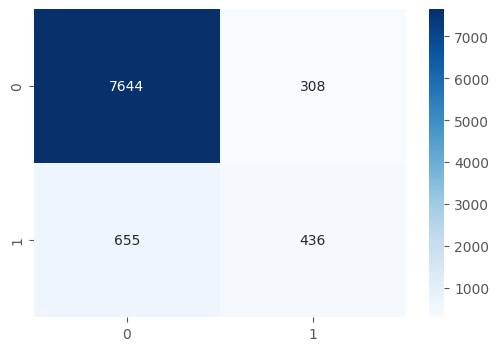

In [94]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.show()

In [62]:
# Tree Depth

print(dt_model.get_depth())

5


In [95]:
# Number of Leaf Nodes

print(dt_model.get_n_leaves())

32


In [96]:
# Feature Importance

importance = pd.DataFrame({"Feature": X.columns,"Importance": dt_model.feature_importances_})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
11,duration,0.578134
15,poutcome,0.144215
10,month,0.113463
0,age,0.065036
13,pdays,0.057855
8,contact,0.023506
9,day,0.006439
6,housing,0.003712
12,campaign,0.003335
5,balance,0.002783


In [102]:
importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

importance.head(10)

,Feature,Importance
11,duration,0.578134
15,poutcome,0.144215
10,month,0.113463
0,age,0.065036
13,pdays,0.057855
8,contact,0.023506
9,day,0.006439
6,housing,0.003712
12,campaign,0.003335
5,balance,0.002783


In [104]:
# Top 10 Important Features

print(
    importance.head(10)
)

     Feature  Importance
11  duration    0.578134
15  poutcome    0.144215
10     month    0.113463
0        age    0.065036
13     pdays    0.057855
8    contact    0.023506
9        day    0.006439
6    housing    0.003712
12  campaign    0.003335
5    balance    0.002783


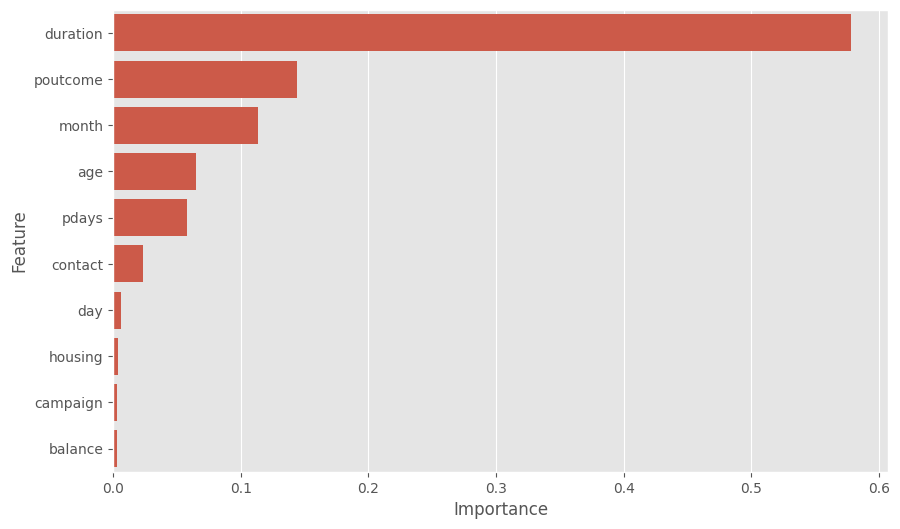

In [97]:
# Top Feature Visualization

plt.figure(figsize=(10,6))

sns.barplot(x="Importance", y="Feature", data=importance.sort_values(by="Importance", ascending=False).head(10))

plt.show()

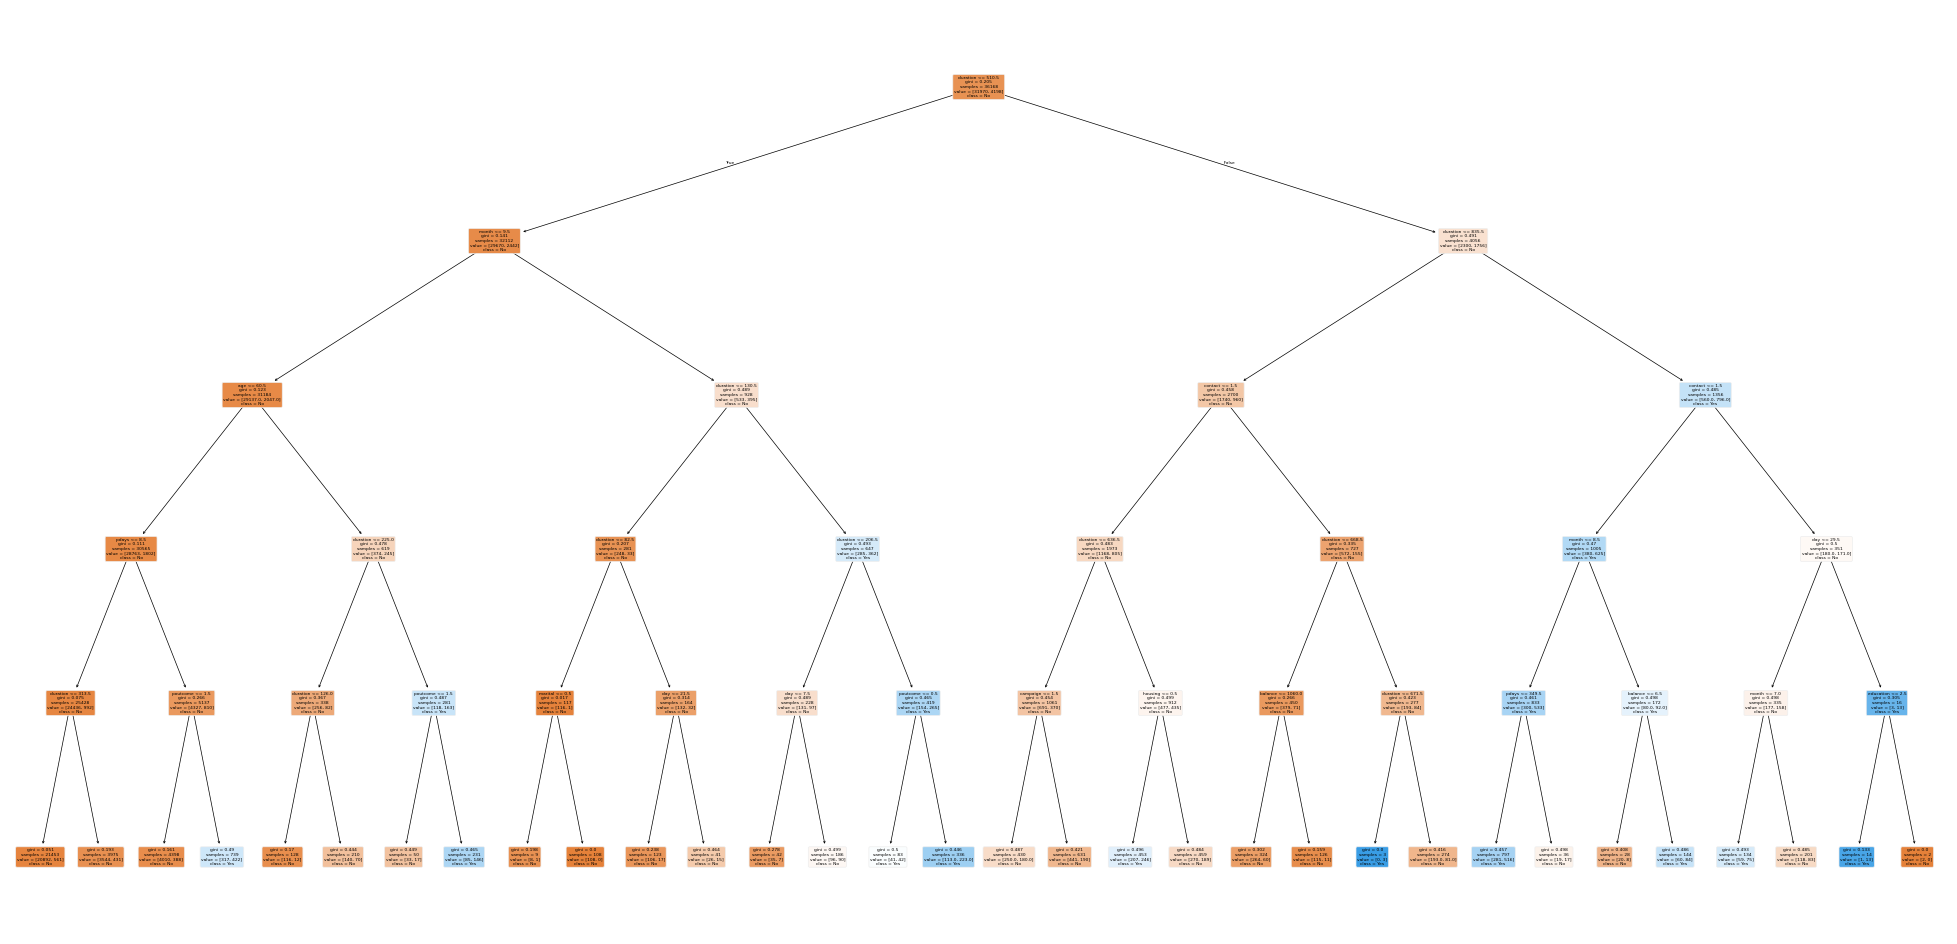

In [98]:
# Decision Tree Visualization

plt.figure(figsize=(25,12))

plot_tree(dt_model,feature_names=X.columns,class_names=["No","Yes"],filled=True,rounded=True)

plt.show()

In [99]:
# Save Model

joblib.dump(dt_model,"bank_decision_tree_model.pkl")

['bank_decision_tree_model.pkl']

In [100]:
# Load Saved Model

loaded_model = joblib.load("bank_decision_tree_model.pkl")

# Business Impact


1. Identify Potential Customers
2. Reduce Marketing Costs
3. Improve Campaign Efficiency
4. Increase Conversion Rate
5. Improve Customer Targeting



# Project Conclusion


The Decision Tree Classifier successfully
predicted whether a customer would subscribe
to a term deposit.

The model achieved good accuracy and
provided interpretable decision rules.

This project demonstrates how machine
learning can support banking marketing
campaigns and customer targeting.
